# Part 4: Controlled Experiments

**Goal:** With proper gradient flow established (scale=1.0, lr=1e-2, clip=10.0), we can now run controlled experiments:
- **Experiment A:** Temperature scaling ($\alpha$) — sharpen or smooth attention
- **Experiment B:** Split learning rates (Q/K vs V/H) — balance attention structure vs content learning

In Part 3, we fixed the gradient vanishing problem. Now we can explore what makes self-attention work effectively.


## 4.1 Setup

We'll use the working parameters from Part 3: `scale=1.0`, `lr=1e-2`, `clip=10.0`.

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Core functions
# ============================================================

def generate_argmax_sample(dim=4, value_range=(0, 10), seed=None):
    if seed is not None:
        np.random.seed(seed)
    x = np.random.randint(value_range[0], value_range[1], size=(dim,))
    return x, np.full((dim,), np.max(x))


def row_softmax(scores: np.ndarray) -> np.ndarray:
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)


def attention_forward(hidden_layer, W_Q, W_K, W_V, W_H, return_cache=False, softmax_fn=None):
    if softmax_fn is None:
        softmax_fn = row_softmax
    d_k = W_Q.shape[1]
    Q, K, V = hidden_layer @ W_Q, hidden_layer @ W_K, hidden_layer @ W_V
    scores = (Q @ K.T) / np.sqrt(d_k)
    A = softmax_fn(scores)
    Z = A @ V
    H = Z @ W_H
    if not return_cache:
        return H
    return H, {"Q": Q, "K": K, "V": V, "scores": scores, "A": A, "Z": Z, "H": H}


def mse(pred, target):
    return np.mean((pred - target) ** 2)


def attention_step(W_Q, W_K, W_V, W_H, hidden_layer, target, lr=1e-3, clip=1.0, softmax_fn=None):
    pred, cache = attention_forward(hidden_layer, W_Q, W_K, W_V, W_H, return_cache=True, softmax_fn=softmax_fn)
    loss = mse(pred, target)
    dH = (2.0 / pred.size) * (pred - target)

    Z, A, V, Q, K = cache["Z"], cache["A"], cache["V"], cache["Q"], cache["K"]
    dW_H = Z.T @ dH
    dZ = dH @ W_H.T
    dV = A.T @ dZ
    dA = dZ @ V.T
    dS = A * (dA - np.sum(dA * A, axis=1, keepdims=True))

    d_k = W_Q.shape[1]
    dQ = (dS @ K) / np.sqrt(d_k)
    dK = (dS.T @ Q) / np.sqrt(d_k)
    dW_Q, dW_K, dW_V = hidden_layer.T @ dQ, hidden_layer.T @ dK, hidden_layer.T @ dV

    grad_norms = {"W_Q": float(np.linalg.norm(dW_Q)), "W_K": float(np.linalg.norm(dW_K)),
                  "W_V": float(np.linalg.norm(dW_V)), "W_H": float(np.linalg.norm(dW_H))}

    dW_Q, dW_K = np.clip(dW_Q, -clip, clip), np.clip(dW_K, -clip, clip)
    dW_V, dW_H = np.clip(dW_V, -clip, clip), np.clip(dW_H, -clip, clip)

    return W_Q - lr*dW_Q, W_K - lr*dW_K, W_V - lr*dW_V, W_H - lr*dW_H, loss, cache, grad_norms


def make_hidden_and_target(x_raw, y_raw, W_embed, scale=10.0):
    x = (np.array(x_raw, dtype=np.float64).reshape(-1, 1)) / scale
    y = (np.array(y_raw, dtype=np.float64).reshape(-1, 1)) / scale
    return x @ W_embed, y @ W_embed


def decode_embedding_to_scalar(embedded, W_embed, scale=10.0):
    w = W_embed.reshape(-1)
    return (embedded @ w) / (w @ w + 1e-12) * scale


def attention_row_entropy(A: np.ndarray) -> float:
    eps = 1e-12
    P = np.clip(A, eps, 1.0)
    return float(np.mean(-np.sum(P * np.log(P), axis=1)))


def attention_row_entropy_normalized(A: np.ndarray) -> float:
    """Normalized mean row entropy in [0,1]. 0=sharp, 1=uniform."""
    eps = 1e-12
    P = np.clip(A, eps, 1.0)
    P = P / np.sum(P, axis=1, keepdims=True)
    H = -np.sum(P * np.log(P), axis=1)
    return float(np.mean(H / (np.log(P.shape[1]) + eps)))


def attention_diagnostics(alpha, logits, alpha_prev=None, V=None):
    """Per-sample diagnostics: entropy, sharpness, logit scale, gradient flow health."""
    eps = 1e-9
    row_entropy = -np.sum(alpha * np.log(alpha + eps), axis=-1)
    max_weights = np.max(alpha, axis=-1)
    support = 1.0 / (np.sum(alpha**2, axis=-1) + eps)       # effective support (1=one-hot, n=uniform)
    sensitivity = alpha * (1 - alpha)                         # α(1-α): softmax Jacobian diagonal

    movement = None
    if alpha_prev is not None and alpha.shape == alpha_prev.shape:
        movement = np.linalg.norm(alpha - alpha_prev, 'fro')

    return {
        "entropy_mean": float(np.mean(row_entropy)),
        "entropy_std": float(np.std(row_entropy)),
        "entropy_min": float(np.min(row_entropy)),
        "max_mean": float(np.mean(max_weights)),
        "max_std": float(np.std(max_weights)),
        "max_weights": max_weights.flatten(),
        "support_mean": float(np.mean(support)),
        "support_std": float(np.std(support)),
        "support_all": support.flatten(),
        "sensitivity_mean": float(np.mean(sensitivity)),
        "sensitivity_max": float(np.max(sensitivity)),
        "logit_abs_mean": float(np.mean(np.abs(logits))),
        "logit_max": float(np.max(np.abs(logits))),
        "logit_std": float(np.std(logits)),
        "movement": movement,
        "output_norm": float(np.linalg.norm(alpha @ V)) if V is not None else None,
        "alpha_flat": alpha.flatten(),
    }


# ============================================================
# Training loop (reusable across all experiments)
# ============================================================

def train_attention_model(
    train_set, d_model=8, init_scale=0.1, scale=10.0, lr=1e-3, clip=1.0,
    epochs=5000, seed_embed=7, seed_weights=7, verbose=True,
    track_diagnostics=False, diagnostic_freq=100,
):
    """Train attention on argmax task. Returns dict with histories + weights."""
    rng_embed = np.random.default_rng(seed_embed)
    W_embed = init_scale * rng_embed.standard_normal((1, d_model))

    rng_w = np.random.default_rng(seed_weights)
    wq = init_scale * rng_w.standard_normal((d_model, d_model))
    wk = init_scale * rng_w.standard_normal((d_model, d_model))
    wv = init_scale * rng_w.standard_normal((d_model, d_model))
    wh = init_scale * rng_w.standard_normal((d_model, d_model))

    loss_hist, entropy_hist = [], []
    grad_hist = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}

    # Diagnostics storage (populated only when track_diagnostics=True)
    diag_keys = ["entropy_mean", "entropy_std", "entropy_min", "max_mean", "max_std",
                 "support_mean", "support_std", "sensitivity_mean",
                 "logit_abs_mean", "logit_max", "logit_std", "movement", "output_norm"]
    diagnostics = {"epochs": [], **{k: [] for k in diag_keys},
                   "grad_relative": {"W_Q": [], "W_K": [], "W_V": [], "W_H": []},
                   "alpha_snapshots": [], "max_weights_snapshots": [], "support_snapshots": []}

    prev_alpha = None

    for ep in range(epochs):
        ep_losses, ep_ent, ep_g = [], [], {k: [] for k in grad_hist}
        ep_diag = []

        for x_raw, y_raw in train_set:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=scale)
            wq, wk, wv, wh, loss, cache, gnorms = attention_step(
                wq, wk, wv, wh, hidden, target, lr=lr, clip=clip)
            if np.isfinite(loss):
                ep_losses.append(loss)
                ep_ent.append(attention_row_entropy_normalized(cache["A"]))
                for k in ep_g:
                    ep_g[k].append(gnorms[k])
                if track_diagnostics:
                    ep_diag.append(attention_diagnostics(
                        cache["A"], cache["scores"], alpha_prev=prev_alpha, V=cache["V"]))
                    prev_alpha = cache["A"].copy()

        loss_hist.append(np.mean(ep_losses))
        entropy_hist.append(np.mean(ep_ent))
        for k in grad_hist:
            grad_hist[k].append(np.mean(ep_g[k]))

        if track_diagnostics and ep_diag:
            diagnostics["epochs"].append(ep)
            for dk in diag_keys:
                vals = [d[dk] for d in ep_diag if d[dk] is not None]
                diagnostics[dk].append(np.mean(vals) if vals else 0.0)
            for k in ["W_Q", "W_K", "W_V", "W_H"]:
                w_norm = np.linalg.norm({"W_Q": wq, "W_K": wk, "W_V": wv, "W_H": wh}[k])
                diagnostics["grad_relative"][k].append(grad_hist[k][-1] / (w_norm + 1e-12))
            if ep % diagnostic_freq == 0 or ep == epochs - 1:
                diagnostics["alpha_snapshots"].append((ep, np.concatenate([d["alpha_flat"] for d in ep_diag])))
                diagnostics["max_weights_snapshots"].append((ep, np.concatenate([d["max_weights"] for d in ep_diag])))
                diagnostics["support_snapshots"].append((ep, np.concatenate([d["support_all"] for d in ep_diag])))

        if verbose and (ep + 1) % 1000 == 0:
            print(f"  Epoch {ep+1:5d}: loss={loss_hist[-1]:.6f}, entropy={entropy_hist[-1]:.4f}")

    return {
        "loss": loss_hist, "entropy": entropy_hist, "grad": grad_hist,
        "diagnostics": diagnostics if track_diagnostics else None,
        "cfg": {"scale": scale, "lr": lr, "clip": clip, "init_scale": init_scale, "epochs": epochs},
        "W_embed": W_embed,
        "weights": {"W_Q": wq, "W_K": wk, "W_V": wv, "W_H": wh},
    }


# ============================================================
# Forward-pass helper
# ============================================================

def forward_from_result(result, x_raw, y_raw):
    """Run forward pass using a trained result dict. Returns pred, cache, y_decoded."""
    cfg = result["cfg"]
    W_embed = result["W_embed"]
    w = result["weights"]
    hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=cfg["scale"])
    pred, cache = attention_forward(hidden, w["W_Q"], w["W_K"], w["W_V"], w["W_H"], return_cache=True)
    y_decoded = decode_embedding_to_scalar(pred, W_embed, scale=cfg["scale"])
    return pred, cache, y_decoded


def evaluate_model(result, test_set):
    """Test-set evaluation: loss, entropy, accuracy, attention-on-max."""
    test_losses, test_ent, attn_on_max = [], [], []
    correct = 0
    for x_raw, y_raw in test_set:
        pred, cache, y_dec = forward_from_result(result, x_raw, y_raw)
        test_losses.append(mse(pred, make_hidden_and_target(x_raw, y_raw, result["W_embed"], scale=result["cfg"]["scale"])[1]))
        test_ent.append(attention_row_entropy_normalized(cache["A"]))
        true_max = np.argmax(x_raw)
        if np.argmax(y_dec) == true_max:
            correct += 1
        attn_on_max.append(np.mean(cache["A"][:, true_max]))
    return {"test_loss": float(np.mean(test_losses)), "test_entropy": float(np.mean(test_ent)),
            "accuracy": correct / len(test_set), "attention_on_max": float(np.mean(attn_on_max))}


# ============================================================
# Plotting helpers
# ============================================================

# Shared style for configs
STYLES = {
    "default (scale=10, lr=1e-3)": {"color": "tab:red",  "ls": "--", "label": "Default"},
    "boosted (scale=1, lr=1e-2)":  {"color": "tab:blue", "ls": "-",  "label": "Boosted"},
}
GRAD_COLORS = {"W_Q": "tab:blue", "W_K": "tab:orange", "W_V": "tab:green", "W_H": "tab:purple"}


def plot_curves(results, keys, titles, ylabels, yscale="linear", figsize=(14, 4)):
    """Plot 1-row of time-series subplots, one line per config."""
    fig, axes = plt.subplots(1, len(keys), figsize=figsize)
    if len(keys) == 1:
        axes = [axes]
    for ax, key, title, ylabel in zip(axes, keys, titles, ylabels):
        for name, res in results.items():
            s = STYLES.get(name, {"color": "tab:gray", "ls": "-", "label": name})
            ax.plot(res[key], s["ls"], color=s["color"], linewidth=2.5, label=s["label"])
        if yscale == "log":
            ax.set_yscale("log")
        ax.set(xlabel="Epoch", ylabel=ylabel, title=title)
        ax.legend(); ax.grid(True)
    plt.tight_layout(); plt.show()


def plot_diagnostic_comparison(results, metric_configs):
    """
    Plot diagnostic time-series. metric_configs is a list of
    (diag_key, title, ylabel, hlines) where hlines is [(y, color, label), ...].
    """
    n = len(metric_configs)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4.5 * rows))
    axes = np.atleast_2d(axes)

    for idx, (dkey, title, ylabel, hlines) in enumerate(metric_configs):
        ax = axes[idx // cols, idx % cols]
        for name, res in results.items():
            diag = res["diagnostics"]
            if not diag:
                continue
            s = STYLES.get(name, {"color": "tab:gray", "ls": "-", "label": name})
            epochs = diag["epochs"]
            data = diag[dkey]
            # movement starts at epoch 1
            if dkey == "movement":
                ax.plot(epochs[1:], data[1:], s["ls"], color=s["color"], linewidth=2, label=s["label"])
            else:
                ax.plot(epochs, data, s["ls"], color=s["color"], linewidth=2, label=s["label"])
        for y, c, lbl in hlines:
            ax.axhline(y=y, color=c, linestyle=":", alpha=0.7, label=lbl)
        ax.set(xlabel="Epoch", ylabel=ylabel, title=title)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    # Hide unused axes
    for idx in range(n, rows * cols):
        axes[idx // cols, idx % cols].set_visible(False)
    plt.tight_layout(); plt.show()


def plot_histograms_comparison(results, figsize=(14, 12)):
    """Side-by-side before/after histograms for each config."""
    config_names = list(results.keys())
    fig, axes = plt.subplots(3, len(config_names), figsize=figsize)
    if len(config_names) == 1:
        axes = axes.reshape(-1, 1)

    for col, name in enumerate(config_names):
        diag = results[name]["diagnostics"]
        if not diag or len(diag["alpha_snapshots"]) < 2:
            continue
        s = STYLES.get(name, {"color": "tab:gray", "ls": "-", "label": name})

        snap_pairs = [("alpha_snapshots", "Attention weight α", "Attention Distribution", None),
                      ("max_weights_snapshots", "Max attention per row", "Max Attention (→1 sharp)", 1.0),
                      ("support_snapshots", "Effective support (# positions)", "Eff. Support (→1 sharp)", 1.0)]

        for row, (snap_key, xlabel, title, vline) in enumerate(snap_pairs):
            ep0, data0 = diag[snap_key][0]
            epN, dataN = diag[snap_key][-1]
            ax = axes[row, col]
            ax.hist(data0, bins=40, alpha=0.4, color="gray", label=f"Epoch {ep0}", density=True)
            ax.hist(dataN, bins=40, alpha=0.7, color=s["color"], label=f"Epoch {epN}", density=True)
            if vline is not None:
                ax.axvline(x=vline, color="green", linestyle="--", alpha=0.6, label="Ideal")
            ax.set(xlabel=xlabel, ylabel="Density", title=f"{s['label']}: {title}")
            ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


def plot_attention_heatmaps(results, test_set, indices):
    """Attention heatmaps for selected test examples, side-by-side per config."""
    config_names = list(results.keys())
    fig, axes = plt.subplots(len(indices), len(config_names),
                             figsize=(7 * len(config_names), 3 * len(indices)))
    if len(indices) == 1:
        axes = axes.reshape(1, -1)
    if len(config_names) == 1:
        axes = axes.reshape(-1, 1)

    for row, idx in enumerate(indices):
        x_raw, y_raw = test_set[idx]
        max_pos = int(np.argmax(x_raw))
        for col, name in enumerate(config_names):
            _, cache, _ = forward_from_result(results[name], x_raw, y_raw)
            A = cache["A"]
            ax = axes[row, col]
            im = ax.imshow(A, cmap="Blues", vmin=0, vmax=1, aspect="auto")
            ax.axvline(x=max_pos, color="red", linestyle="--", linewidth=2, alpha=0.7)
            for i in range(A.shape[0]):
                for j in range(A.shape[1]):
                    ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center",
                            fontsize=8, color="white" if A[i,j] > 0.5 else "black")
            s = STYLES.get(name, {"color": "tab:gray", "ls": "-", "label": name})
            ax.set(xlabel="Key", ylabel="Query",
                   title=f"{s['label']}: x={[int(v) for v in x_raw]}, max@{int(max_pos)}")
    plt.tight_layout(); plt.show()


def pick_representative_indices(test_set, want=4):
    """Pick test indices with diverse sequence lengths."""
    seen = {}
    for i, (x, _) in enumerate(test_set):
        L = len(x)
        if L not in seen:
            seen[L] = i
        if len(seen) >= want:
            break
    return list(seen.values())[:want]


print("All functions loaded.")

All functions loaded.


In [38]:
# Global configuration
d_model = 8
init_scale = 0.1

# Boosted parameters (from Part 3)
DEFAULT_SCALE = 1.0   # NOT 10.0
DEFAULT_LR = 1e-2     # NOT 1e-3
DEFAULT_CLIP = 10.0   # NOT 1.0

# Dataset
N = 400
min_len, max_len = 2, 8

rng_data = np.random.default_rng(123)
dataset = []
for _ in range(N):
    L = int(rng_data.integers(min_len, max_len + 1))
    x, y = generate_argmax_sample(dim=L, value_range=(0, 10))
    dataset.append((x, y))

train_frac = 0.8
train_N = int(N * train_frac)
train_set = dataset[:train_N]
test_set = dataset[train_N:]

print(f"Dataset: {N} samples, train={len(train_set)}, test={len(test_set)}")
print(f"Sequence lengths: {min_len}–{max_len}")

# Embedding (shared across experiments)
rng = np.random.default_rng(0)
W_embed = init_scale * rng.standard_normal((1, d_model))

Dataset: 400 samples, train=320, test=80
Sequence lengths: 2–8


## 4.2 Helper Functions for Experiments

In [39]:
def attention_forward_alpha(hidden_layer, W_Q, W_K, W_V, W_H, alpha=1.0, return_cache=False):
    """
    Forward pass with temperature scaling.
    
    alpha > 1 → sharper attention (lower entropy)
    alpha < 1 → smoother attention (higher entropy)
    """
    d_k = W_Q.shape[1]
    Q = hidden_layer @ W_Q
    K = hidden_layer @ W_K
    V = hidden_layer @ W_V
    scores = alpha * (Q @ K.T) / np.sqrt(d_k)  # alpha scales BEFORE softmax
    A = row_softmax(scores)
    Z = A @ V
    H = Z @ W_H
    if not return_cache:
        return H
    cache = {"Q": Q, "K": K, "V": V, "scores": scores, "A": A, "Z": Z, "H": H}
    return H, cache


def attention_step_split_lr(W_Q, W_K, W_V, W_H, hidden_layer, target,
                            alpha=1.0, lr_qk=1e-3, lr_vh=1e-3, clip=1.0):
    """
    SGD step with separate learning rates for Q/K vs V/H.
    
    Hypothesis: Q/K gradients can be "starved" relative to V/H.
    Giving Q/K a higher lr may help attention structure emerge.
    """
    pred, cache = attention_forward_alpha(hidden_layer, W_Q, W_K, W_V, W_H, 
                                          alpha=alpha, return_cache=True)
    loss = mse(pred, target)
    dH = (2.0 / pred.size) * (pred - target)
    
    Z, A, V, Q, K = cache["Z"], cache["A"], cache["V"], cache["Q"], cache["K"]
    dW_H = Z.T @ dH
    dZ = dH @ W_H.T
    
    dV = A.T @ dZ
    dA = dZ @ V.T
    dS = A * (dA - np.sum(dA * A, axis=1, keepdims=True))
    
    d_k = W_Q.shape[1]
    dQ = (dS @ K) / np.sqrt(d_k)
    dK = (dS.T @ Q) / np.sqrt(d_k)
    
    dW_Q = hidden_layer.T @ dQ
    dW_K = hidden_layer.T @ dK
    dW_V = hidden_layer.T @ dV
    
    grad_norms = {
        "W_Q": float(np.linalg.norm(dW_Q)),
        "W_K": float(np.linalg.norm(dW_K)),
        "W_V": float(np.linalg.norm(dW_V)),
        "W_H": float(np.linalg.norm(dW_H)),
    }
    
    dW_Q = np.clip(dW_Q, -clip, clip)
    dW_K = np.clip(dW_K, -clip, clip)
    dW_V = np.clip(dW_V, -clip, clip)
    dW_H = np.clip(dW_H, -clip, clip)
    
    # Different learning rates!
    W_Q = W_Q - lr_qk * dW_Q
    W_K = W_K - lr_qk * dW_K
    W_V = W_V - lr_vh * dW_V
    W_H = W_H - lr_vh * dW_H
    
    return W_Q, W_K, W_V, W_H, float(loss), cache, grad_norms

In [40]:
def train_and_evaluate(alpha=1.0, epochs=300, lr=None, lr_qk=None, lr_vh=None,
                       clip=DEFAULT_CLIP, scale=DEFAULT_SCALE, seed=0):
    """
    Full training run with all metrics tracked.
    
    Returns dict with: loss_hist, entropy_hist, grad_norm_hist, 
                       final weights, test metrics
    """
    # Handle learning rate defaults
    if lr is not None:
        lr_qk = lr_qk or lr
        lr_vh = lr_vh or lr
    else:
        lr_qk = lr_qk or DEFAULT_LR
        lr_vh = lr_vh or DEFAULT_LR
    
    # Initialize weights
    rng = np.random.default_rng(seed)
    wq = init_scale * rng.standard_normal((d_model, d_model))
    wk = init_scale * rng.standard_normal((d_model, d_model))
    wv = init_scale * rng.standard_normal((d_model, d_model))
    wh = init_scale * rng.standard_normal((d_model, d_model))
    
    loss_hist = []
    entropy_hist = []
    grad_norm_hist = {"W_Q": [], "W_K": [], "W_V": [], "W_H": []}
    
    for _ in range(epochs):
        ep_losses, ep_entropies = [], []
        ep_gnorms = {k: [] for k in grad_norm_hist}
        
        for x_raw, y_raw in train_set:
            hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=scale)
            wq, wk, wv, wh, loss, cache, gnorms = attention_step_split_lr(
                wq, wk, wv, wh, hidden, target,
                alpha=alpha, lr_qk=lr_qk, lr_vh=lr_vh, clip=clip
            )
            if np.isfinite(loss):
                ep_losses.append(loss)
                ep_entropies.append(attention_row_entropy_normalized(cache["A"]))
                for k in ep_gnorms:
                    ep_gnorms[k].append(gnorms[k])
        
        loss_hist.append(float(np.mean(ep_losses)) if ep_losses else np.nan)
        entropy_hist.append(float(np.mean(ep_entropies)) if ep_entropies else np.nan)
        for k in grad_norm_hist:
            grad_norm_hist[k].append(float(np.mean(ep_gnorms[k])) if ep_gnorms[k] else np.nan)
    
    # Test evaluation
    test_losses, test_entropies = [], []
    for x_raw, y_raw in test_set[:50]:
        hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=scale)
        pred, cache = attention_forward_alpha(hidden, wq, wk, wv, wh, alpha=alpha, return_cache=True)
        test_losses.append(mse(pred, target))
        test_entropies.append(attention_row_entropy_normalized(cache["A"]))
    
    return {
        "alpha": float(alpha),
        "epochs": int(epochs),
        "lr_qk": float(lr_qk),
        "lr_vh": float(lr_vh),
        "final_train_loss": float(loss_hist[-1]),
        "test_mse": float(np.mean(test_losses)),
        "test_entropy": float(np.mean(test_entropies)),
        "loss_hist": loss_hist,
        "entropy_hist": entropy_hist,
        "grad_norm_hist": grad_norm_hist,
        "weights": (wq, wk, wv, wh),
    }


def make_label(r):
    """Create readable label for plot legends."""
    if r["lr_qk"] != r["lr_vh"]:
        return f"α={r['alpha']}, qk={r['lr_qk']:.0e}, vh={r['lr_vh']:.0e}"
    return f"α={r['alpha']}, lr={r['lr_qk']:.0e}"

In [41]:
def plot_results(results):
    """Plot loss, entropy, and gradient norms for multiple experiments."""
    styles = ["-o", "--s", "-.^", ":D", "-v", "--x"]
    
    # Loss + entropy
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for i, r in enumerate(results):
        label = make_label(r)
        ms = styles[i % len(styles)]
        axes[0].plot(r["loss_hist"], ms, markevery=20, markersize=5, label=label)
        axes[1].plot(r["entropy_hist"], ms, markevery=20, markersize=5, label=label)
    
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train loss")
    axes[0].set_title("Loss curves")
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Normalized entropy")
    axes[1].set_title("Attention entropy (0=sharp, 1=uniform)")
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Gradient norms
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    for idx, wname in enumerate(["W_Q", "W_K", "W_V", "W_H"]):
        ax = axes[idx // 2][idx % 2]
        for i, r in enumerate(results):
            label = make_label(r)
            ms = styles[i % len(styles)]
            ax.plot(r["grad_norm_hist"][wname], ms, markevery=20, markersize=5, label=label)
        ax.set_yscale("log")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Grad norm")
        ax.set_title(f"Gradient norms: {wname}")
        ax.legend(fontsize=8)
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

---

## 4.3 Experiment A: Temperature Scaling ($\alpha$)

### Hypothesis

Scaling attention scores by $\alpha$ before softmax changes the sharpness:

$$
A = \text{softmax}\left(\alpha \cdot \frac{QK^T}{\sqrt{d_k}}\right)
$$

- $\alpha > 1$ → larger score differences → **sharper** attention (lower entropy)
- $\alpha < 1$ → smaller score differences → **smoother** attention (higher entropy)

**Prediction:** Higher $\alpha$ should help the model focus on the argmax position more quickly.

In [49]:
# Experiment A configurations
configs_A = [
    {"alpha": 0.5, "epochs": 500, "lr": DEFAULT_LR},
    {"alpha": 1.0, "epochs": 500, "lr": DEFAULT_LR},
    {"alpha": 2.0, "epochs": 500, "lr": DEFAULT_LR},
    {"alpha": 4.0, "epochs": 500, "lr": DEFAULT_LR},
]

print("Running Experiment A: Temperature Scaling")
print("=" * 50)

results_A = []
for cfg in configs_A:
    r = train_and_evaluate(**cfg, seed=0)
    results_A.append(r)
    print(f"α={r['alpha']:.1f}: train_loss={r['final_train_loss']:.6f}, "
          f"test_mse={r['test_mse']:.6f}, entropy={r['test_entropy']:.4f}")

Running Experiment A: Temperature Scaling
α=0.5: train_loss=0.011151, test_mse=0.012255, entropy=0.9454
α=1.0: train_loss=0.011120, test_mse=0.012257, entropy=0.9405
α=2.0: train_loss=0.011092, test_mse=0.012258, entropy=0.9356
α=4.0: train_loss=0.011066, test_mse=0.012258, entropy=0.9306


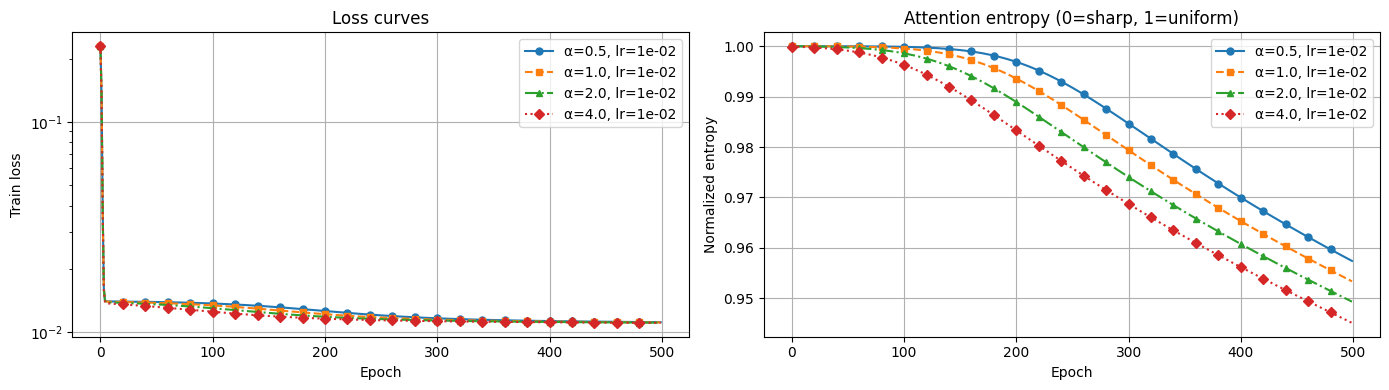

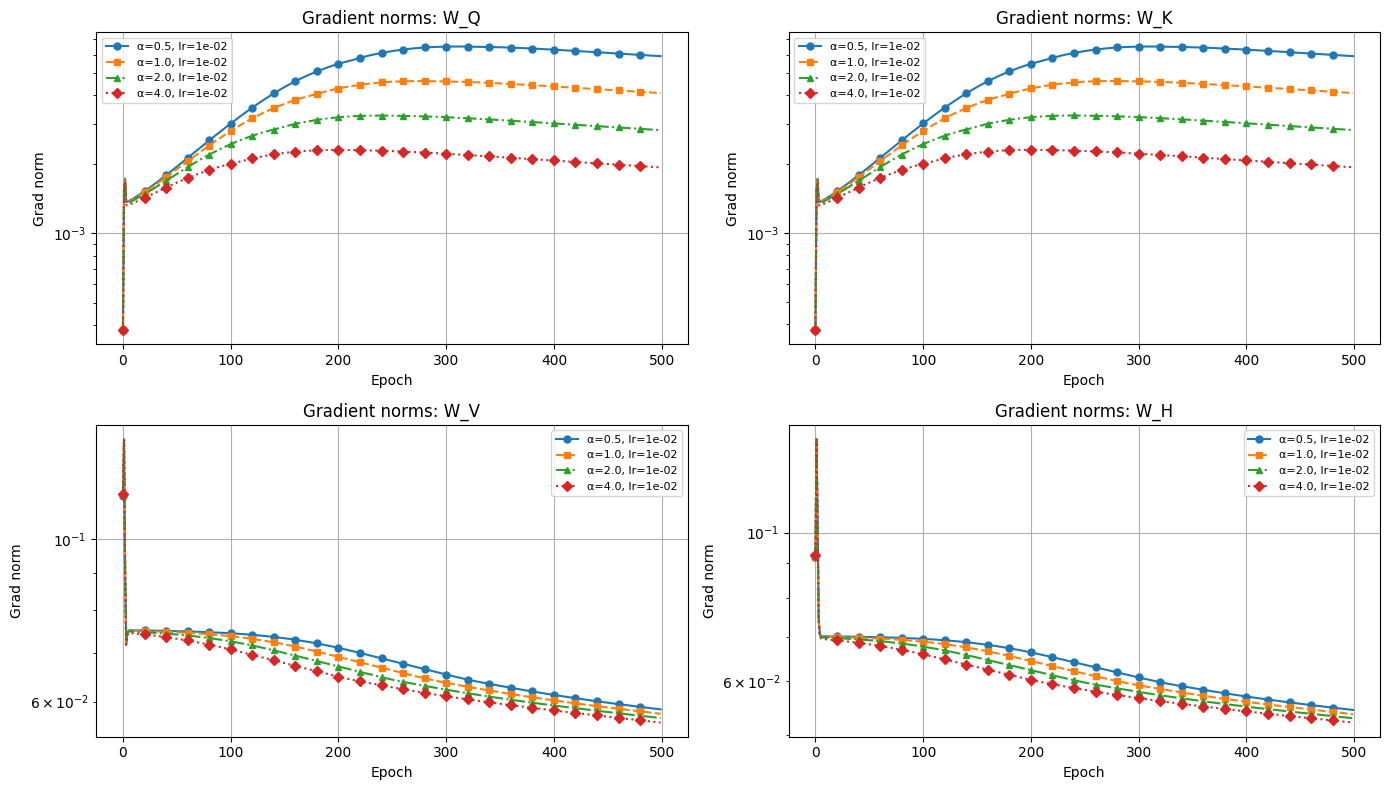

In [50]:
plot_results(results_A)

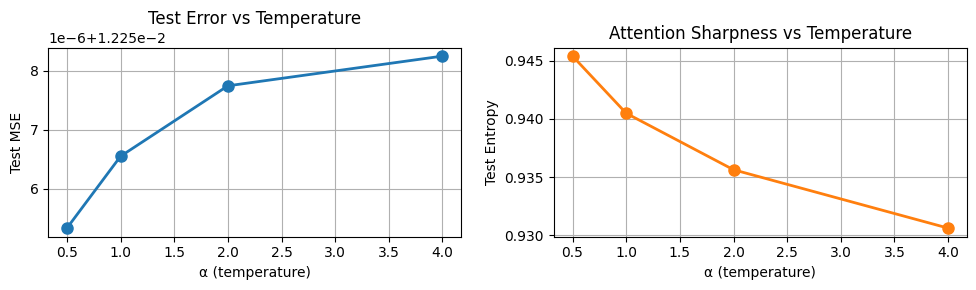

In [51]:
# Summary plot: alpha vs metrics
alphas = [r["alpha"] for r in results_A]
test_mse = [r["test_mse"] for r in results_A]
test_ent = [r["test_entropy"] for r in results_A]

fig, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].plot(alphas, test_mse, "o-", linewidth=2, markersize=8)
ax[0].set_xlabel("α (temperature)")
ax[0].set_ylabel("Test MSE")
ax[0].set_title("Test Error vs Temperature")
ax[0].grid(True)

ax[1].plot(alphas, test_ent, "o-", linewidth=2, markersize=8, color="tab:orange")
ax[1].set_xlabel("α (temperature)")
ax[1].set_ylabel("Test Entropy")
ax[1].set_title("Attention Sharpness vs Temperature")
ax[1].grid(True)

plt.tight_layout()
plt.show()

### Experiment A Interpretation

*Fill in after running:*

- **Observation:** ...
- **Best $\alpha$:** ...
- **Why?** ...

---

## 4.4 Experiment B: Split Learning Rates

### Hypothesis

In attention, gradients flow:
- **Loss → W_H → W_V → W_K/W_Q** (long path for Q/K)

The Q/K matrices control *which positions attend to which*. The V/H matrices control *what values are passed*.

**Gradient starvation:** Q/K may receive smaller gradients because they're further from the loss.

**Fix:** Give Q/K a higher learning rate to compensate.

In [52]:
# Experiment B configurations
configs_B = [
    # Baseline: uniform lr
    {"alpha": 2.0, "epochs": 200, "lr_qk": 1e-2, "lr_vh": 1e-2},
    # Boost Q/K
    {"alpha": 2.0, "epochs": 200, "lr_qk": 2e-2, "lr_vh": 1e-2},
    {"alpha": 2.0, "epochs": 200, "lr_qk": 5e-2, "lr_vh": 1e-2},
    # Boost V/H instead (control)
    {"alpha": 2.0, "epochs": 200, "lr_qk": 1e-2, "lr_vh": 5e-2},
]

print("Running Experiment B: Split Learning Rates")
print("=" * 50)

results_B = []
for cfg in configs_B:
    r = train_and_evaluate(**cfg, seed=0)
    results_B.append(r)
    print(f"lr_qk={r['lr_qk']:.0e}, lr_vh={r['lr_vh']:.0e}: "
          f"train_loss={r['final_train_loss']:.6f}, test_mse={r['test_mse']:.6f}")

Running Experiment B: Split Learning Rates
lr_qk=1e-02, lr_vh=1e-02: train_loss=0.011840, test_mse=0.012534
lr_qk=2e-02, lr_vh=1e-02: train_loss=0.011181, test_mse=0.012254
lr_qk=5e-02, lr_vh=1e-02: train_loss=0.010769, test_mse=0.012053
lr_qk=1e-02, lr_vh=5e-02: train_loss=0.012055, test_mse=0.012613


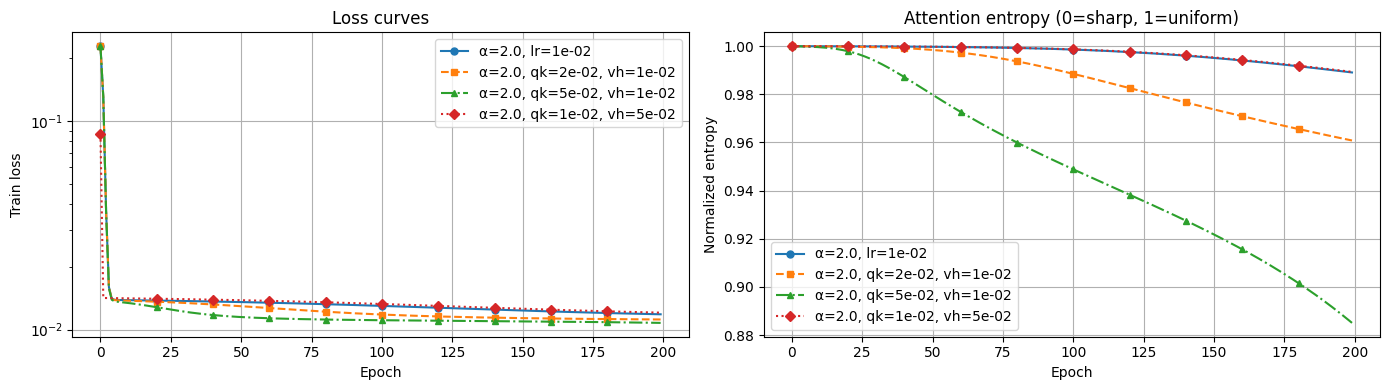

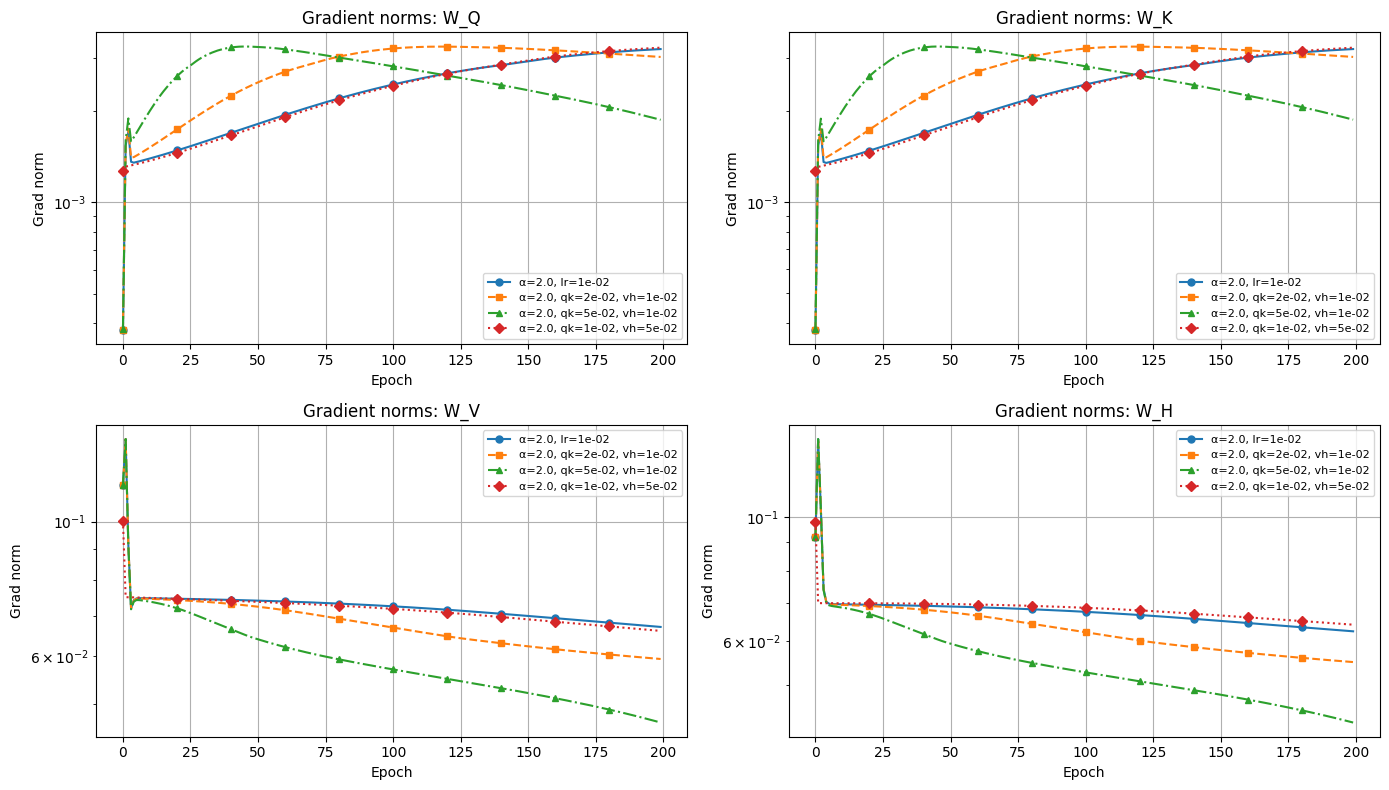

In [53]:
plot_results(results_B)

### Experiment B Interpretation

*Fill in after running:*

- **Does boosting lr_qk help?** ...
- **Does boosting lr_vh help?** ...
- **Conclusion about gradient starvation:** ...

---

## 4.5 Inspecting Trained Models

Let's examine attention patterns from the best model.

In [54]:
# Pick best result from Experiment A
best_A = min(results_A, key=lambda r: r["test_mse"])
wq, wk, wv, wh = best_A["weights"]

print(f"Best model from Exp A: α={best_A['alpha']}, test_mse={best_A['test_mse']:.6f}")
print("\n" + "="*60)

# Show predictions on test examples
for i in range(min(5, len(test_set))):
    x_raw, y_raw = test_set[i]
    hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=DEFAULT_SCALE)
    pred, cache = attention_forward_alpha(hidden, wq, wk, wv, wh, 
                                          alpha=best_A["alpha"], return_cache=True)
    
    yhat = decode_embedding_to_scalar(pred, W_embed, scale=DEFAULT_SCALE)
    
    # What position has the max value?
    true_max_pos = int(np.argmax(x_raw))
    true_max_val = int(np.max(x_raw))
    pred_max_pos = int(np.argmax(yhat))
    
    # How much attention is on the correct position?
    attn_on_max = np.mean(cache['A'][:, true_max_pos])  # avg across all query positions
    
    print(f"\nExample {i+1}:")
    print(f"  Input:       {x_raw}")
    print(f"  True max:    {true_max_val} at position {true_max_pos}")
    print(f"  Prediction:  {np.round(yhat, 2)}")
    print(f"  Pred argmax: position {pred_max_pos} (value={yhat[pred_max_pos]:.2f})")
    print(f"  Attention on max position: {attn_on_max:.1%}")
    print(f"  Sample attn row[0]: {np.round(cache['A'][0], 2)}")
    
    # Check if argmax prediction is correct (this is the actual task!)
    error = np.abs(yhat - y_raw).mean()
    if pred_max_pos == true_max_pos and error < 0.5:
        print(f"  ✓ CORRECT argmax, low error ({error:.2f})")
    elif pred_max_pos == true_max_pos:
        print(f"  ~ Correct argmax position, but high error ({error:.2f})")
    else:
        print(f"  ✗ WRONG argmax (predicted pos {pred_max_pos}, should be {true_max_pos}), error={error:.2f}")

Best model from Exp A: α=0.5, test_mse=0.012255


Example 1:
  Input:       [6 6 2 6 4 7]
  True max:    7 at position 5
  Prediction:  [7.67 7.67 7.3  7.67 7.49 7.74]
  Pred argmax: position 5 (value=7.74)
  Attention on max position: 21.2%
  Sample attn row[0]: [0.19 0.19 0.09 0.19 0.13 0.22]
  ~ Correct argmax position, but high error (0.59)

Example 2:
  Input:       [9 3]
  True max:    9 at position 0
  Prediction:  [10.9   9.27]
  Pred argmax: position 0 (value=10.90)
  Attention on max position: 72.4%
  Sample attn row[0]: [0.82 0.18]
  ~ Correct argmax position, but high error (1.08)

Example 3:
  Input:       [0 3 6 3 6 7 8]
  True max:    8 at position 6
  Prediction:  [6.47 7.22 7.85 7.22 7.85 8.03 8.2 ]
  Pred argmax: position 6 (value=8.20)
  Attention on max position: 21.0%
  Sample attn row[0]: [0.14 0.14 0.14 0.14 0.14 0.14 0.14]
  ~ Correct argmax position, but high error (0.52)

Example 4:
  Input:       [4 3 7 3 9 6 4 8]
  True max:    9 at position 4
  Prediction: 

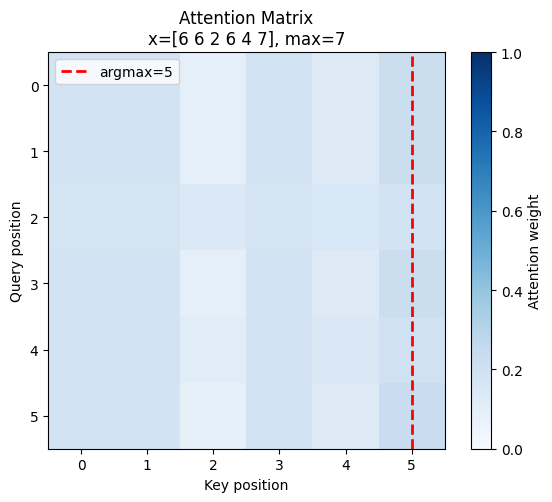


Ideally, all rows should concentrate weight on column 5 (the argmax position).


In [55]:
# Visualize attention matrix
x_raw, y_raw = test_set[0]
hidden, target = make_hidden_and_target(x_raw, y_raw, W_embed, scale=DEFAULT_SCALE)
pred, cache = attention_forward_alpha(hidden, wq, wk, wv, wh,
                                      alpha=best_A["alpha"], return_cache=True)

A = cache["A"]
n = A.shape[0]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(A, cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("Key position")
ax.set_ylabel("Query position")
ax.set_title(f"Attention Matrix\nx={x_raw}, max={np.max(x_raw)}")
plt.colorbar(im, ax=ax, label="Attention weight")

# Mark argmax position
argmax_pos = np.argmax(x_raw)
ax.axvline(argmax_pos, color="red", linestyle="--", linewidth=2, label=f"argmax={argmax_pos}")
ax.legend()

plt.tight_layout()
plt.show()

print(f"\nIdeally, all rows should concentrate weight on column {argmax_pos} (the argmax position).")

---

## 4.6 Summary & Report Template

### What We Learned

1. **Broadcasting bug:** Missing `keepdims=True` breaks softmax normalization

2. **Gradient signal:** Input scaling (`scale`) dramatically affects gradient magnitude; tiny gradients = no learning

3. **Temperature ($\alpha$):** Higher values → sharper attention → faster convergence on this task

4. **Split learning rates:** May help if Q/K gradients are starved relative to V/H

### Report Structure

```
1. Background
   - Self-attention mechanism
   - The argmax broadcast task

2. Failure Analysis
   - Broadcasting bug: what broke and why
   - Gradient signal issue: why entropy was constant

3. Fixes Applied
   - keepdims=True in softmax
   - Boosted parameters (scale, lr, clip)

4. Experiments
   - Experiment A: Temperature scaling
     - Hypothesis → Method → Results → Interpretation
   - Experiment B: Split learning rates
     - Hypothesis → Method → Results → Interpretation

5. Results
   - Best configuration found
   - Attention patterns inspection
   - Test set performance

6. Limitations
   - Single-head attention only
   - Toy task (may not generalize)
   - No systematic hyperparameter search
```

### Key Hyperparameters (Final Reference)

| Parameter | Default | Effect | Tuning Advice |
|-----------|---------|--------|---------------|
| `scale` | 10.0 → **1.0** | Input normalization | Lower if gradients vanish |
| `lr` | 1e-3 → **1e-2** | Learning rate | Raise if loss plateaus |
| `clip` | 1.0 → **10.0** | Gradient clipping | Raise if gradients are clipped |
| `alpha` | 1.0 | Temperature | Higher → sharper attention |
| `lr_qk` | = lr | Q/K learning rate | Raise if attention won't focus |
| `lr_vh` | = lr | V/H learning rate | Usually keep equal to lr |